<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 1 — Introducción con PhysioNet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->
<font color="#7F000E" size=3> Nivel: Ingeniería Biomédica — 7.º ciclo / 4.º año </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Importación, exploración, visualización y exportación de ECG </font><br>
</div>

---

## Objetivos

Al finalizar este laboratorio, el estudiante será capaz de:

1. Acceder a una base de datos de señales fisiológicas de PhysioNet.
2. Cargar un registro ECG mediante la librería `wfdb`.
3. Identificar la frecuencia de muestreo, número de canales, nombres de canales y duración.
4. Construir el eje temporal de una señal discreta.
5. Visualizar una señal ECG mediante diferentes representaciones.
6. Analizar un segmento de la señal.
7. Exportar un segmento ECG a formato `.wav`.
8. Interpretar las diferencias entre una señal biomédica y una señal de audio.
9. Formular observaciones básicas sobre la morfología y amplitud de un ECG.

> **Importante:** el archivo WAV generado es una representación de la señal ECG en un formato reproducible por herramientas de audio. No significa que el ECG sea originalmente una señal acústica.



## 1. Introducción

Las señales biomédicas son señales generadas por procesos fisiológicos. Algunos ejemplos son:

- ECG — electrocardiograma
- EEG — electroencefalograma
- EMG — electromiograma
- EOG — electrooculograma
- PPG — fotopletismografía

En este laboratorio trabajaremos con una señal **ECG real** obtenida de **PhysioNet**.

PhysioNet proporciona acceso a numerosas bases de datos fisiológicas. Una de las bases más conocidas es la **MIT-BIH Arrhythmia Database**, que contiene registros electrocardiográficos anotados.

### Concepto fundamental: DATABASE + RECORD

Un registro no debe identificarse solamente por su número.

Por ejemplo:

```python
DATABASE = "mitdb"
RECORD = "100"
```

significa que estamos solicitando el registro `100` de la base de datos `mitdb`.

El mismo número de registro puede tener un significado diferente si pertenece a otra base de datos. Por ello, siempre debemos interpretar:

```text
BASE DE DATOS + RECORD
```

como la identificación del registro.



## 2. Parámetros configurables

En esta sección el estudiante podrá cambiar los parámetros principales del laboratorio.

### Parámetros

| Parámetro | Descripción | Ejemplo |
|---|---|---|
| `DATABASE` | Base de datos de PhysioNet | `"mitdb"` |
| `RECORD` | Identificador del registro | `"100"` |
| `CHANNEL` | Canal que se desea analizar | `0` |
| `DURATION` | Duración del segmento en segundos | `10` |
| `OUTPUT_WAV` | Nombre del archivo WAV | `"ecg_100.wav"` |

### Pregunta inicial

Antes de ejecutar el código, responda:

**¿Qué cree que representa `CHANNEL = 0`?**
Anote su hipótesis y compruébela después de ejecutar el notebook.
`Hipótesis: Representa el primer canal que se desea analizar, es decir comienza en el índice 0.`


In [ ]:

# ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")


Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_0.wav


`Conclusión: Se cumple la hipótesis según la tabla y el código, el primer canal que se desea analizar se encuentra en el índice 0 pero del registro seleccionado, en este caso el registro 100.`


## 3. Instalación de librerías

Utilizaremos:

- **WFDB:** acceso a registros de PhysioNet.
- **NumPy:** procesamiento numérico.
- **Pandas:** organización de datos.
- **Matplotlib:** visualización.
- **SciPy:** exportación de la señal a WAV.


In [ ]:
!pip install uv

In [ ]:

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib


In [ ]:

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")


Librerías importadas correctamente.



## 4. Cargar el registro desde PhysioNet

La función principal será:

```python
wfdb.rdrecord()
```

Usaremos:

```python
record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)
```

El argumento `pn_dir` indica que el registro se obtendrá desde una base de datos disponible en PhysioNet.


In [ ]:

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")


Registro cargado correctamente.



## 5. Explorar la información del registro

Antes de procesar una señal biomédica es necesario conocer sus características.

Algunos parámetros importantes son:

- `fs`: frecuencia de muestreo.
- `sig_len`: número de muestras.
- `n_sig`: número de canales.
- `sig_name`: nombres de los canales.
- `units`: unidades de las señales.


In [ ]:

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)


INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos



### Preguntas de análisis 1

1. ¿Cuál es la frecuencia de muestreo del registro? `360hz`
2. ¿Cuántos canales tiene? `2, MLII y V5`
3. ¿Cómo se llama el canal seleccionado? `MLII`
4. ¿Cuál es la duración total del registro? `1805.56 segundos`
5. Si `fs = 360 Hz`, ¿cuántas muestras se adquieren en 1 segundo? `360 muestras`
6. ¿Cuántas muestras corresponden a un segmento de 10 segundos? `3600 muestras`



## 6. Identificación del canal

El parámetro:

```python
record.sig_name
```

permite conocer qué señal corresponde a cada canal.

Por ejemplo, conceptualmente:

```text
CHANNEL 0 → primer canal
CHANNEL 1 → segundo canal
...
```

No debemos asumir que todos los registros tienen los mismos canales. Siempre debemos consultar los metadatos del registro.


In [ ]:

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")


Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII



## 7. Extraer la señal ECG

Las muestras de la señal se encuentran en:

```python
record.p_signal
```

Esta estructura contiene:

```text
filas    → muestras
columnas → canales
```

Por tanto:

```python
signal = record.p_signal[:, CHANNEL]
```

selecciona todas las muestras del canal indicado.


In [ ]:

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])


Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]



## 8. Crear el eje temporal

Una señal digital está formada por muestras.

Si la frecuencia de muestreo es:

\[
f_s
\]

entonces el intervalo entre muestras es:

\[
T_s = \frac{1}{f_s}
\]

y el instante asociado a la muestra `n` es:

\[
t[n] = \frac{n}{f_s}
\]

Esta relación es fundamental para interpretar correctamente una señal biomédica.


In [ ]:

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")


Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos



# 9. GRÁFICA 1 — Señal ECG completa

En esta primera visualización observaremos todo el registro.

### Objetivo

Reconocer:

- eje temporal;
- amplitud;
- duración;
- comportamiento general de la señal;
- posibles cambios de morfología.


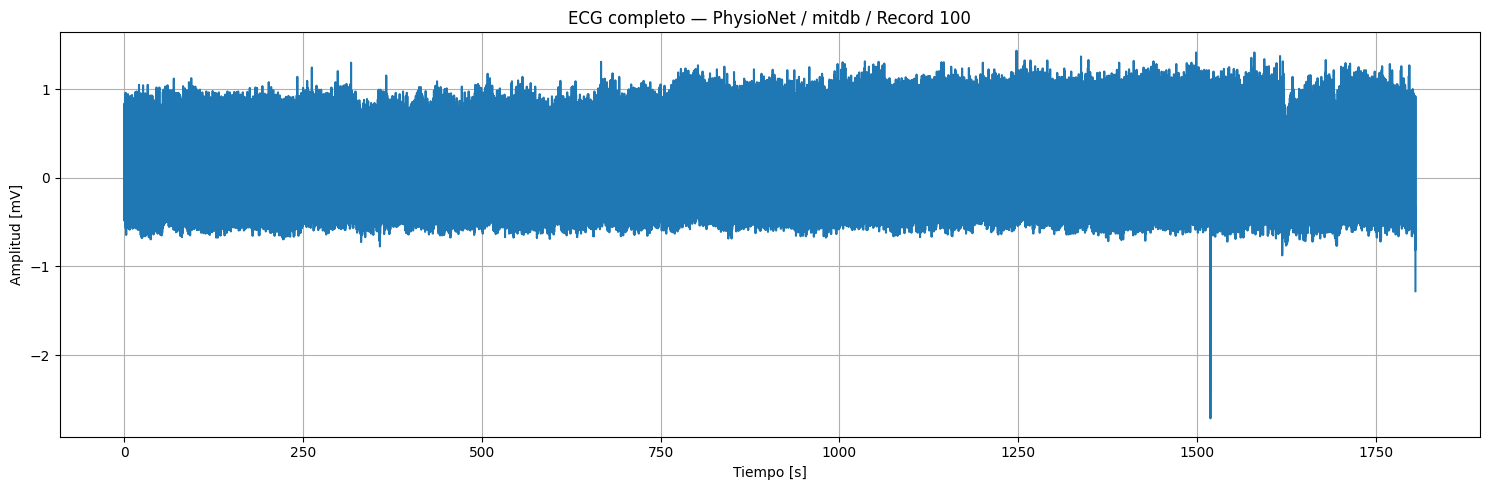

In [ ]:

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 2

1. ¿La señal presenta una amplitud constante?
`No, pese a que se muestre constante por valores de tiempos largos, existen valores atipicos más allá de 1 mV`
2. ¿Se pueden identificar visualmente complejos QRS?
`Se impide la identicación de los complejos QRS debido a la acumulación de datos`
3. ¿La morfología permanece igual durante todo el registro?
`La morfología general se mantiene, pero aparecen pequeñas variaciones por ruido`
4. ¿Se observa ruido?
`Sí se observa ruido`
5. ¿Qué ventajas tiene visualizar una señal durante varios minutos?
`Permite observar tendencias en la actividad cardíaca, detectar eventos poco frecuentes, evaluar la estabilidad de la señal a lo largo del tiempo y analizar variables externas que afectan a la señales tales como el ruido`
6. ¿Qué limitaciones tiene una gráfica demasiado extensa?
`La acumulación de datos no permite la identificación de ondas individuales o información importante, en este caso complejos QRS y pese a su extensión si presenta ruido su utilida resulta baja a comparación de señales con corta duración pero un ruido menor.`



# 10. GRÁFICA 2 — Segmento ECG ampliado

Una señal completa puede dificultar el análisis de eventos individuales.

Por ello seleccionaremos solamente los primeros `DURATION` segundos.


In [ ]:

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")


Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


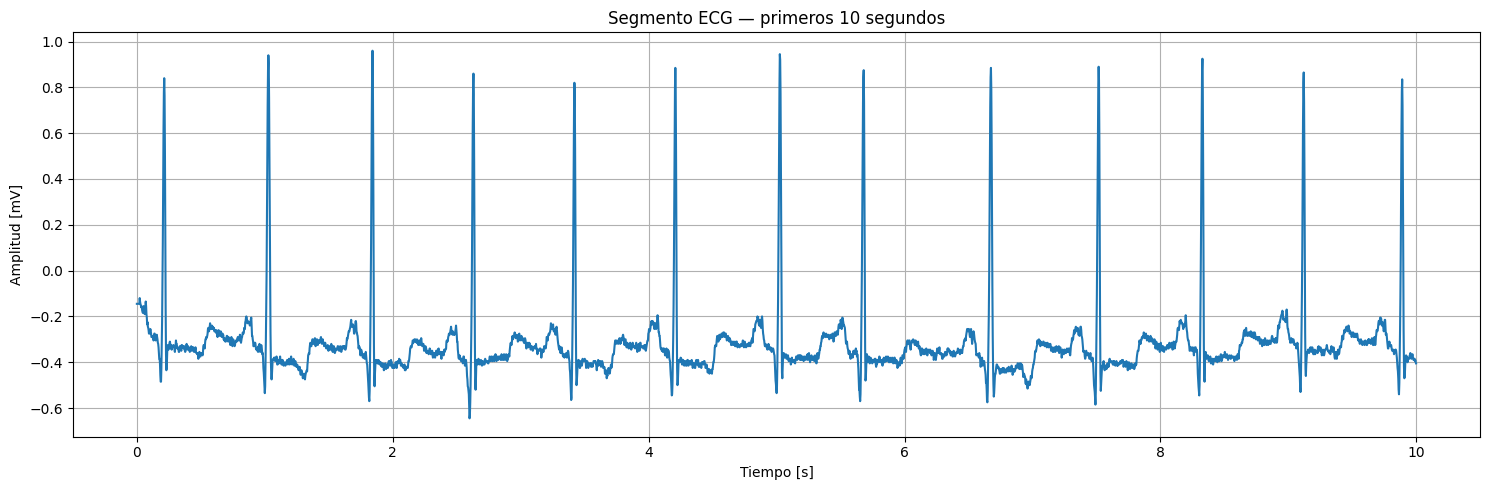

In [ ]:

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Actividad

Observe cuidadosamente la gráfica.

Intente identificar:

- onda P;
- complejo QRS;
- onda T;
- intervalo entre complejos QRS;
- posibles artefactos.

> **Nota:** la identificación automática de ondas no forma parte de este laboratorio. Aquí el objetivo es desarrollar una primera capacidad de observación de señales biomédicas.



# 11. GRÁFICA 3 — Histograma de amplitudes

El histograma permite observar cómo se distribuyen los valores de amplitud de la señal.

Podemos utilizarlo para introducir conceptos como:

- media;
- dispersión;
- valores extremos;
- distribución de amplitudes.


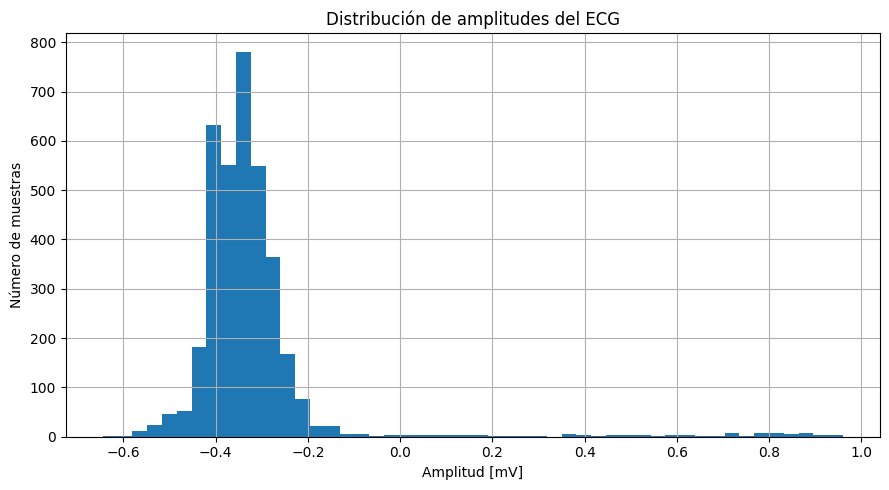

In [ ]:

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 3

1. ¿Dónde se concentra la mayor cantidad de muestras? `En el rango de -0.6 a -0.2 mV. Especificamente en -0.3 mV`
2. ¿La distribución parece simétrica? `No, debido a que pese a existir valores en ascendente también dentro de estos valores que van en ascendente existe un caída y ascienden a un valor más alto tras la caída por lo que no es una distribución simétrica`
3. ¿Existen valores extremos? `Sí, pese a que existe una gran cantidad de valores en -0.6 y -0.1 en -0.8 se encuentra otros valores.`
4. ¿Qué podría producir valores de amplitud muy diferentes al valor central? `Los complejos QRS o ruido causado ya sea por el exterior o movimientos del paciente`
5. ¿El histograma conserva información temporal? Explique. `No, como se observa el histograma presenta a la amplitud y el número de muestras como ejes a diferencia de las señales vistas anteriormente que contaban con el tiempo de la señal, el número de muestras es analizado en este caso con su amplitud.`



# 12. GRÁFICA 4 — Representación discreta

Una señal digital no solamente puede representarse como una línea continua visualmente.

También podemos observar sus muestras individuales.

Esto permite introducir el concepto:

\[
x[n]
\]

donde `n` representa el índice de muestra.


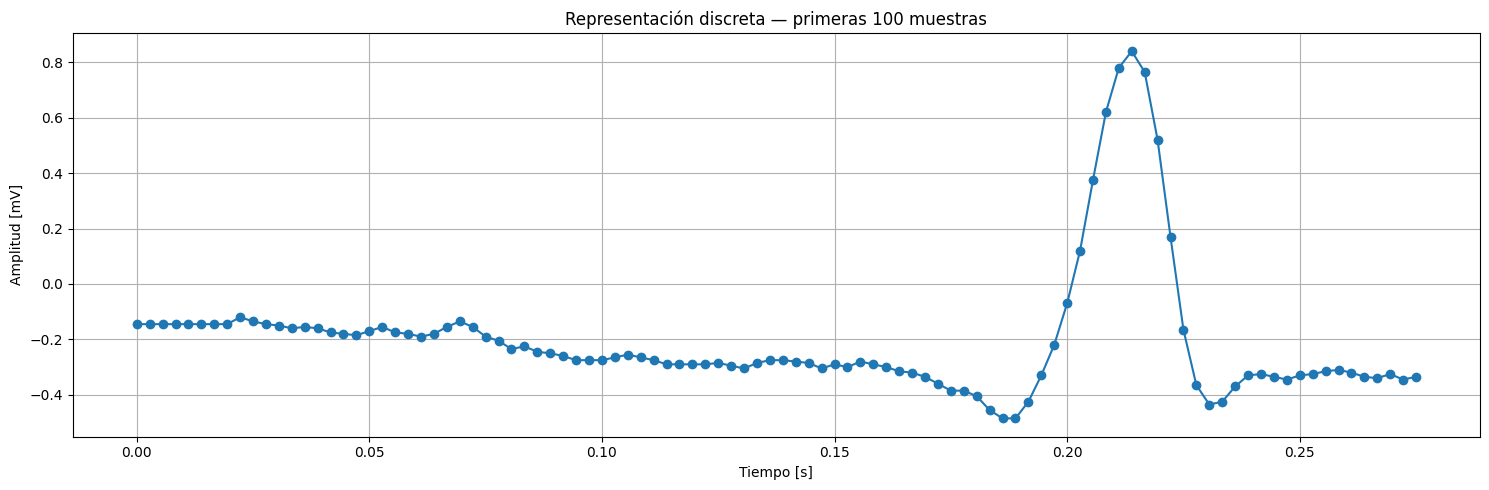

In [ ]:

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()



### Preguntas de análisis 4

1. ¿Cuántas muestras existen por segundo? `100/0.276 = 360 muestras/s`
2. ¿Qué ocurre si aumentamos `fs`? `Si se aumenta la frecuencia fs, se toman más muestras por segundo, por lo que la señal tendría más detalle temporal`
3. ¿Qué ocurre si disminuimos `fs`? `Si disminuye fs, se toman menos muestras por segundo y se pierde detalle, se pueden perder componentes de la señal`
4. ¿Qué representa el eje `n` en una señal discreta? `El eje n representa el índice de cada muestra`
5. ¿Cuál es la relación entre `n`, `fs` y `t`? `Con la fórmula t = nT y T = 1/fs`


# 13. Estadística básica de la señal

Antes de exportar la señal calcularemos algunos parámetros básicos.


In [ ]:

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")


ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3199
Desviación estándar: 0.1702
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050



# 14. Convertir ECG a archivo WAV

El formato WAV es común en aplicaciones de audio. Sin embargo, nuestra señal es un ECG.

Para poder almacenarla como WAV realizaremos:

```text
ECG original
     ↓
Eliminar componente media
     ↓
Normalizar amplitud
     ↓
Convertir a int16
     ↓
Guardar WAV
```

### ¿Por qué normalizar?

Los valores del ECG están expresados en unidades fisiológicas, mientras que el WAV suele utilizar representaciones enteras, como `int16`.

Utilizaremos el rango:

\[
-32768 \leq x \leq 32767
\]

para `int16`.


In [ ]:

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")


Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -8322
Máximo int16    : 32767



# 15. Guardar el archivo WAV

La frecuencia de muestreo del WAV será la misma frecuencia de muestreo del registro ECG.

Esto es importante porque permite conservar la separación temporal entre las muestras.


In [ ]:

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)


Archivo WAV generado correctamente:
ecg_record_100_channel_0.wav



# 16. Reproducir el archivo WAV

En Google Colab/Jupyter podemos utilizar un reproductor integrado.


In [1]:

# Reproducir el archivo WAV

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)


NameError: name 'Audio' is not defined


### Preguntas de análisis 5

1. ¿Puede escuchar claramente la señal? `No se puede escuchar claramente la señal`
2. ¿El sonido corresponde a un sonido fisiológico real? `Pese a que no se escuche el sonido con claridad, sí representaría un sonido fisiológico real debido a a la conversión de ECG a WAV`
3. ¿Por qué un ECG puede convertirse a WAV? `Porque las dos son ondas, la señal ECG y WAV varían a lo largo del tiempo, es decir las dos ondas pueden representarse cambios ya sea de amplitud mV en el caso ECG en el tiempo`
4. ¿Qué información se conserva al hacer la conversión? `La morfología de la señal ECG y el intervalo de tiempo entre muestras debido a que se uso la misma frecuencia de muestreo del ECG en el WAV`
5. ¿Qué información fisiológica podría perderse al escucharla?
6. ¿Qué diferencia existe entre representar un ECG gráficamente y reproducirlo como audio? `La señal representada gráficamente te da información exacta de la morfología de ECG en el tiempo en segundos con amplitud en mV, además de distribuiciones tales como el histograma, segmentos acortados de la señal completa para un mejor análisis, representación discreta, etc; sin embargo, al escuchar la señal es útil para el análisis auditivo, las dos serían necesarias para un diagnóstico clínico debido a que dan información útil para el especialista. `



# 17. Descargar el archivo WAV

En Google Colab se puede descargar el archivo generado.


In [ ]:

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 18. Ejercicios propuestos

## Ejercicio 1 — Cambiar de registro

Modifique:


```python
RECORD = 100
```

por otro registro válido de la misma base de datos.

Compare:

- frecuencia de muestreo;
- número de canales;
- nombres de canales;
- morfología;
- amplitud;
- distribución.

### Entregable

Incluya una captura o las cuatro gráficas del nuevo registro y escriba una comparación con el registro original.

---

## Ejercicio 2 — Cambiar de canal

Modifique:

```python
CHANNEL = 0
```

por otro canal disponible.

Responda:

1. ¿Qué nombre tiene el nuevo canal?
2. ¿Tiene las mismas unidades?
3. ¿La morfología es igual?
4. ¿Qué diferencias observa?

---

## Ejercicio 3 — Cambiar la duración

Pruebe:

```python
DURATION = 5
```

```python
DURATION = 20
```

y compare las visualizaciones.

Explique por qué una duración demasiado pequeña o demasiado grande puede dificultar el análisis.



## Ejercicio 4 — Frecuencia de muestreo

Suponga que:

\[
f_s = 360\ Hz
\]

### a)

Calcule el periodo de muestreo: Ts

\[
T_s = \frac{1}{f_s}
\]

`1/f_s = 0.0028`

### b)

¿Cuántas muestras existen en 5 segundos?

`178 muestras`
### c)

¿Cuántas muestras existen en 10 segundos?

`357 muestras`
### d)

Explique qué sucedería si la frecuencia de muestreo fuese reducida significativamente.

`Lo que sucederia es que se tomarian muy pocas muestras y no se realizaría un análisis correcto de la señal, por ejemplo a fs = 5 Hz se tomarían un total de 25 muestras en 5 segundos`

---

## Ejercicio 5 — Análisis de amplitud

Utilizando el segmento seleccionado:

1. Calcule la media.
2. Calcule la desviación estándar.
3. Determine el máximo.
4. Determine el mínimo.
5. Calcule el rango.

Explique qué información proporciona cada parámetro.


Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_0.wav
Parámetros configurados:
Base de datos : mitdb
Registro      : 101
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_101_channel_0.wav
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 22.9 MB/s eta 0:00:00
Librerías importadas correctamente.
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 101
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V1']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V1 [mV]

Canal seleccionado: 0
Nombre            : MLII
Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.345 -0.345 -0.345 -0.345 -0.345 -0.345 -0.345 -0.345 -0.33  -0.32 ]
Frecuencia de muestreo: 360 H

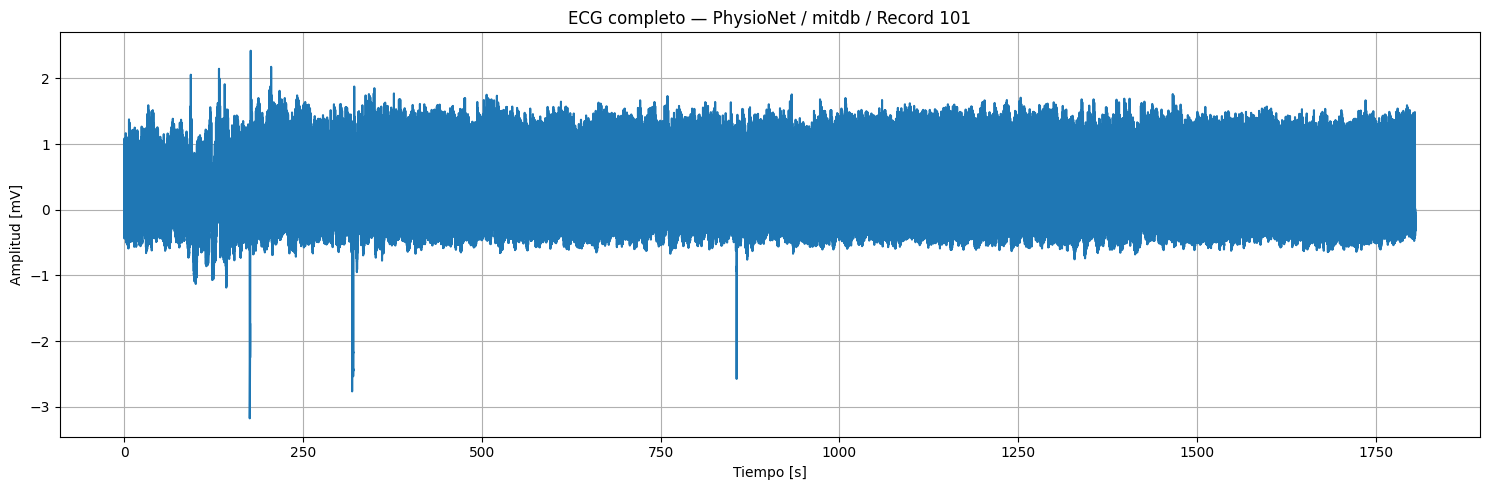

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


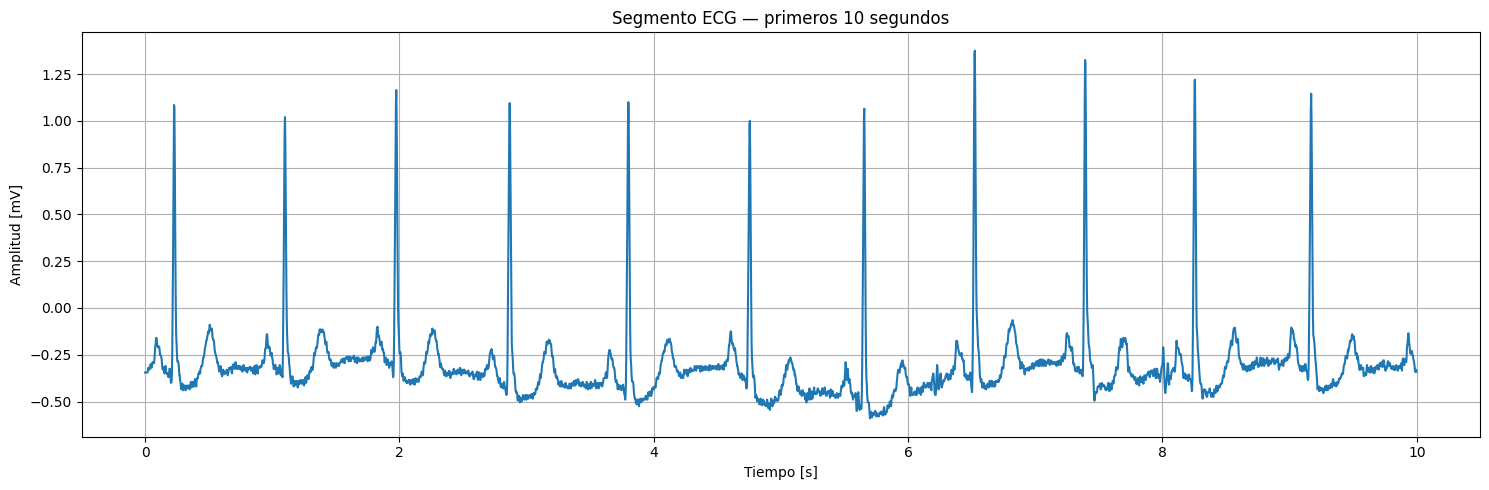

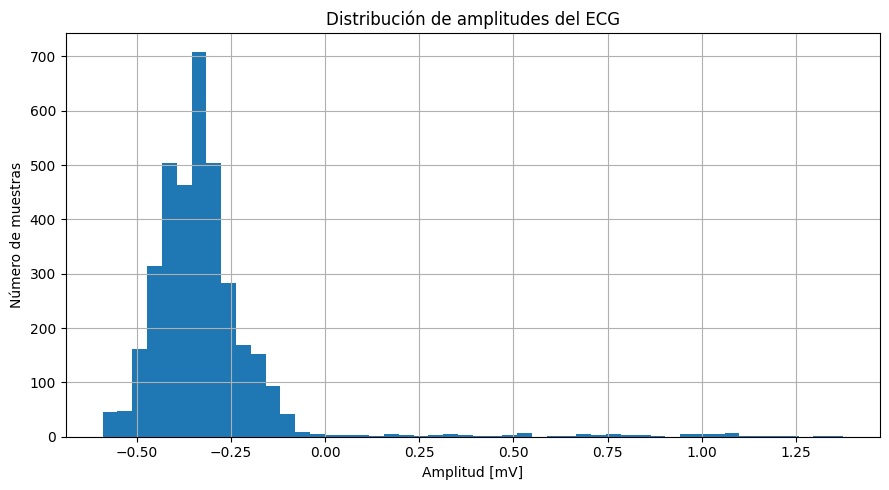

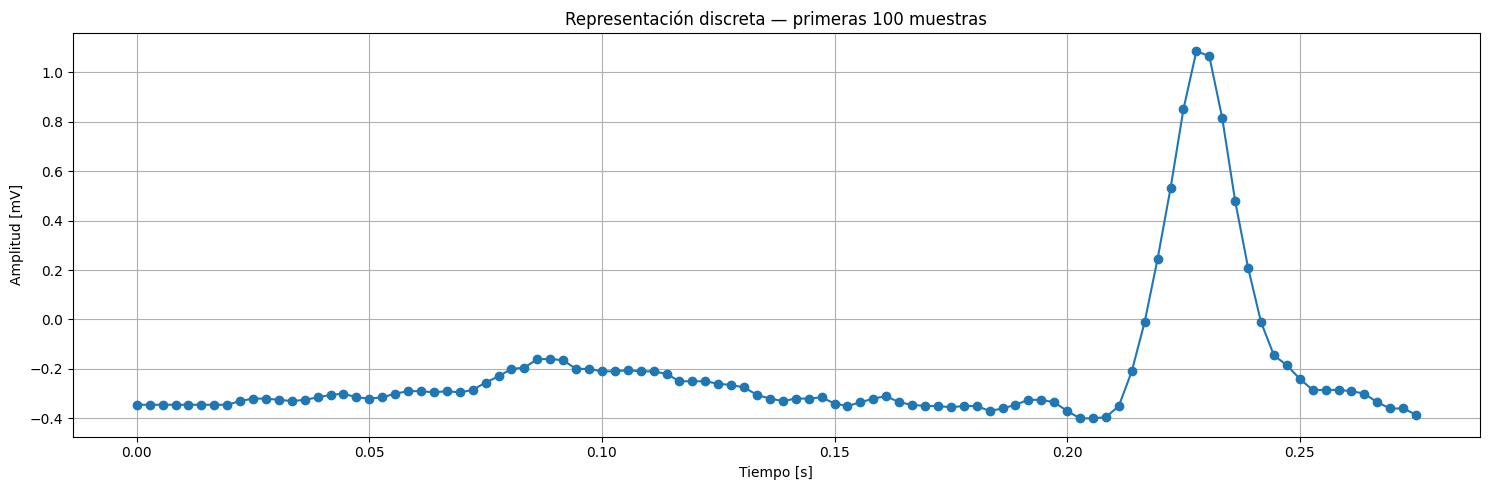

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3120
Desviación estándar: 0.1992
Mínimo            : -0.5900
Máximo            : 1.3750
Rango             : 1.9650


In [ ]:
# Ejercicio 1

# Cambio de la variable RECORD, manteniendo sin embargo el mismo canal.
DATABASE = "mitdb"
RECORD = "101"

CHANNEL = 0

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

!pip install uv

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")



**EJERCICIO 1:**
*   `Se cambió al RECORD = 101, pese a que sea un nuevo RECORD, aún se mantiene la frecuencia de muestreo = 360 Hz al igual que en el RECORD = 100`
*   `Igualmente cuenta con el mismo número de canales, 2 canales`
*   `Sin embargo, pese a ser dos canales, son diferentes. El segundo canal en RECORD = 101 es V1, y en RECORD = 100 es V5, el primer canal de los dos se mantiene igual MLII.`
*   `La morfología es diferente, como se puede apreciar en las dos primeras gráficas la morfología varia notablemente, manteniendo una constancia cercana en ciertas duraciones de tiempo, pero teniendo pequeñas variaciones a una amplitud menor`
*   `Las amplitudes pese a ser cercanas, son diferentes, en el RECORD = 101 la primera gráfica muestra una amplitud máxima, y constante por una duración de tiempo de 2mV, igualmente se comprueba con las gráficas del segmento y la representación discreta donde la amplitud mV es mayor del RECORD = 100 en el cual el máximo de su amplitud es 1.5 mV aproximadamente en la gráfica de ECG completa`
*   `Como se muestra en el histograma las distribuiciones máximas son diferentes, la distribuición máxima en el RECORD = 101 es de 700 en una amplitud de -0.20 mV a comparación del histograma en RECORD = 100, además de mostrar más extremos a comparación del histograma del RECORD = 100 por lo que se concluye que existe una mayor variación de resultados`







Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_1.wav
Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_100_channel_1.wav
Librerías importadas correctamente.
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 1
Nombre            : V5
Número de muestras: 650000
Canal: V5
Unidad: mV

Primeras 10 muestras:
[-0.065 -0.065 -0.065 -0.065 -0.065 -0.065 -0.065 -0.065 -0.08  -0.08 ]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último 

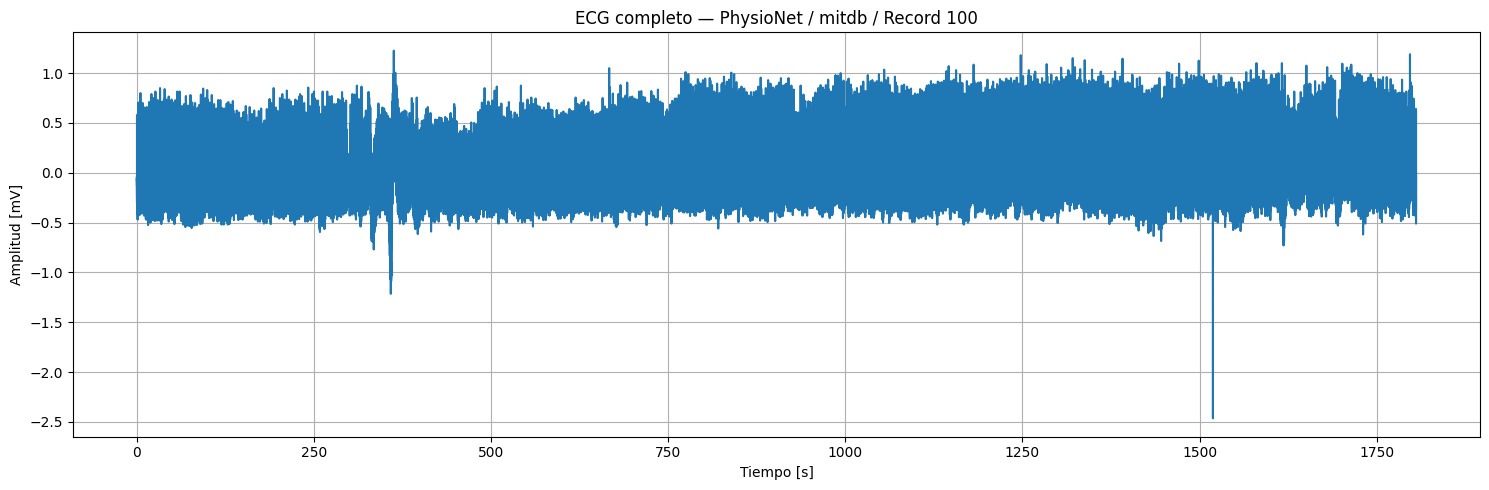

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


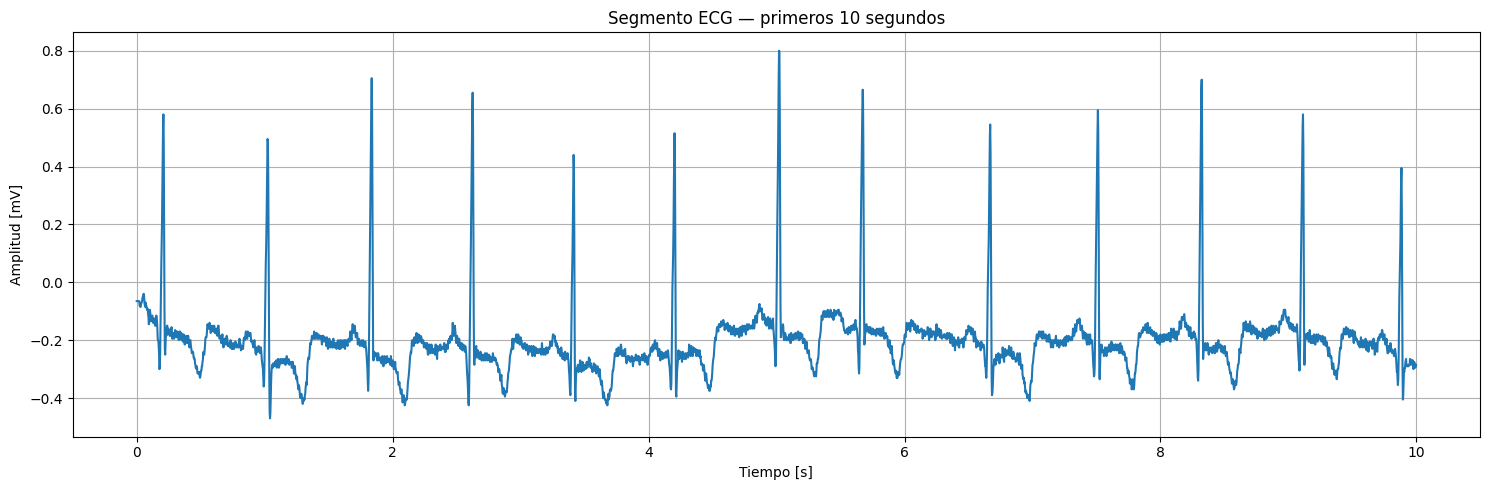

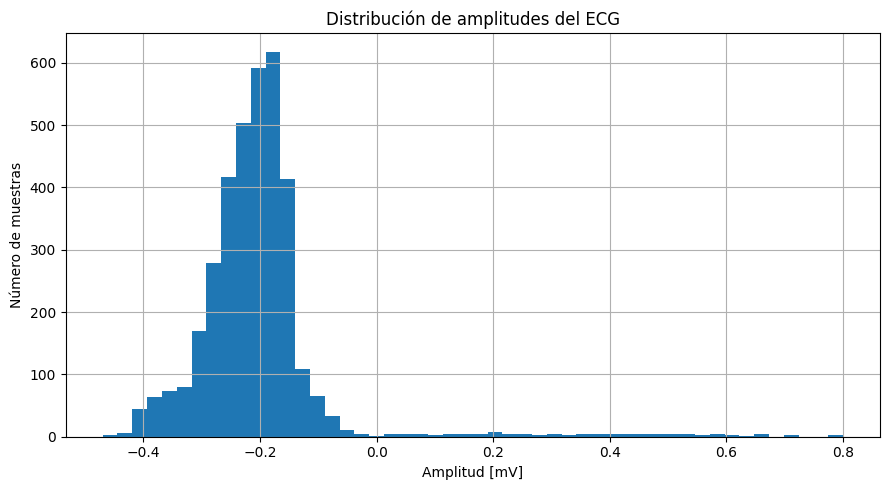

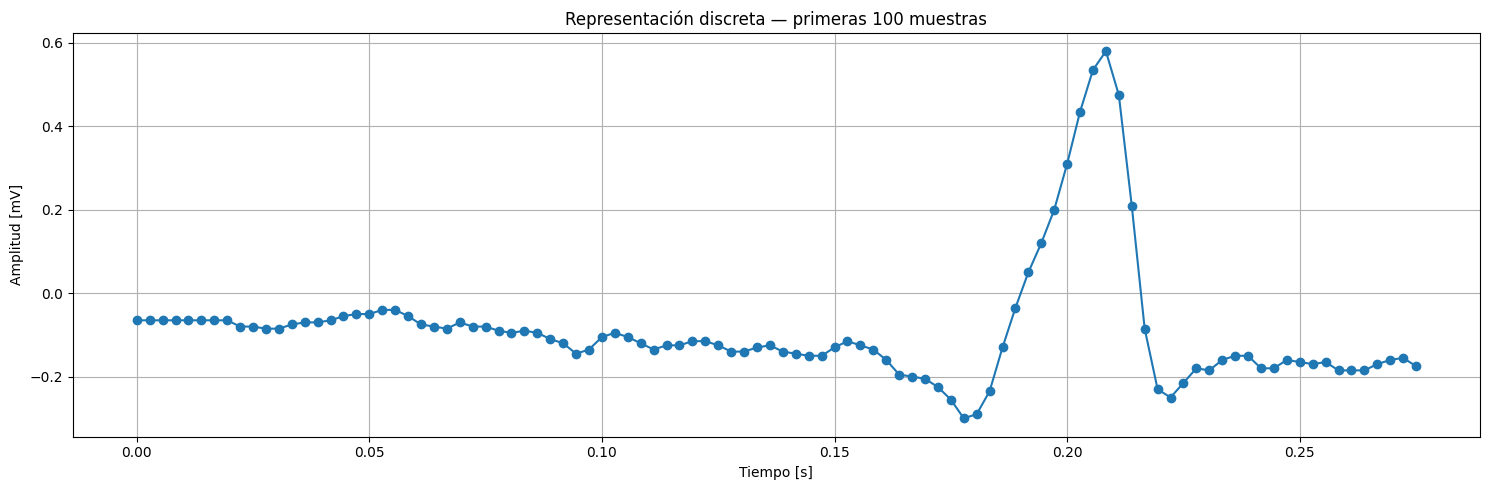

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.2032
Desviación estándar: 0.1225
Mínimo            : -0.4700
Máximo            : 0.8000
Rango             : 1.2700


In [ ]:
# Ejercicio 2

# Cambio de la variable CHANNEL para su comparación con los
# anteriores resultados en RECORD = 100

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 1

DURATION = 10  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

!pip install uv

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

**EJERCICIO 2**
*   `El nombre del nuevo canal es V5 como se muestra en la información del registro, en este caso se utilizó el RECORD = 100`
*   `Sí, igual que en el CHANNEL = 0, el Canal MLII sus unidades son mV`
*   `No, la morfología pese a que es parecida no es igual`
*   `Si bien es cierto la señal es parecida en el ECG completo, cuando se acerca al segmento se ven variaciones en la amplitud en mV vs tiempo en s, en el histograma además se puede notar las diferencias de amplitud con respecto al número de muestras, en el canal MLII llega a un número de muestras máximo de 800 en -0.3 mV aproximadamente; sin embargo, el número de muestras máximo es 600 en -0.25 mV en el canal V5. En la representación discreta nuevamente se demuestra la diferencia de amplitud máxima en el rango de tiempo en segundos`

Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 5 s
Archivo WAV   : ecg_record_100_channel_0.wav
Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 5 s
Archivo WAV   : ecg_record_100_channel_0.wav
Librerías importadas correctamente.
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII
Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Últim

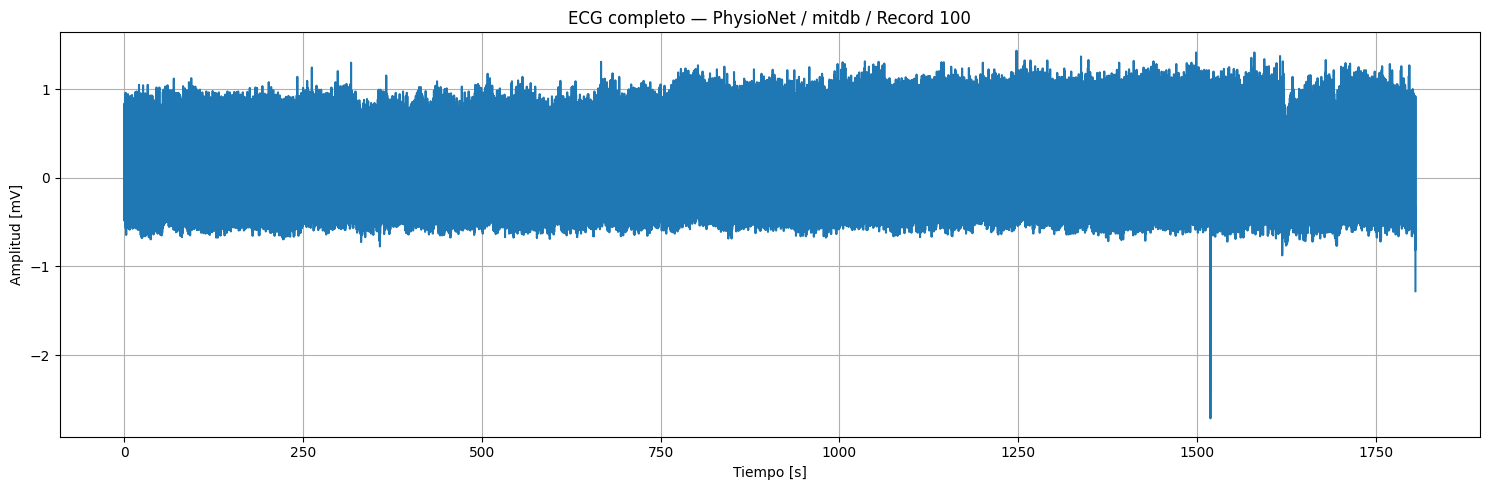

Duración solicitada : 5 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 1800


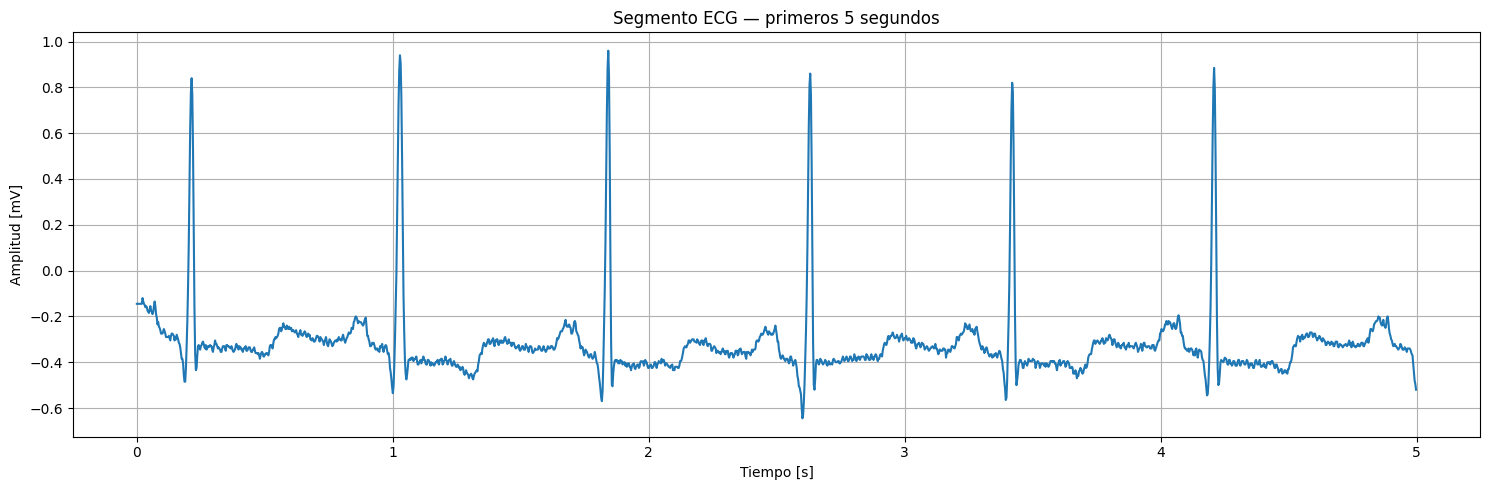

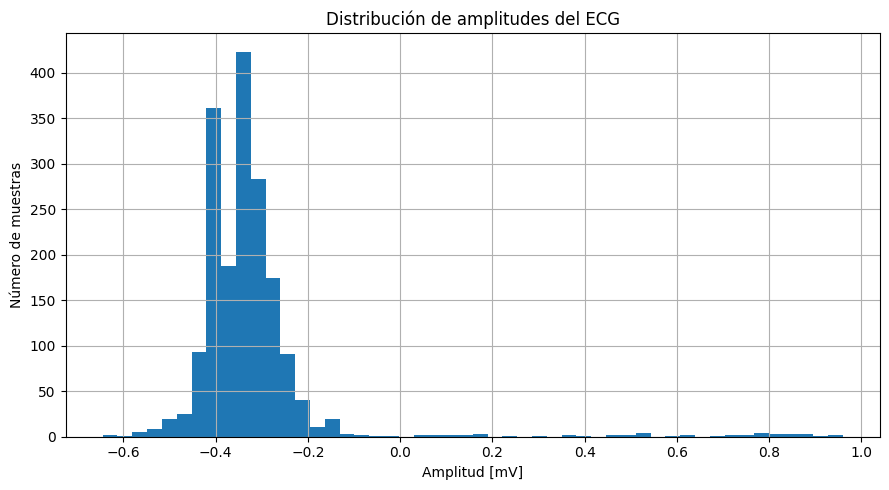

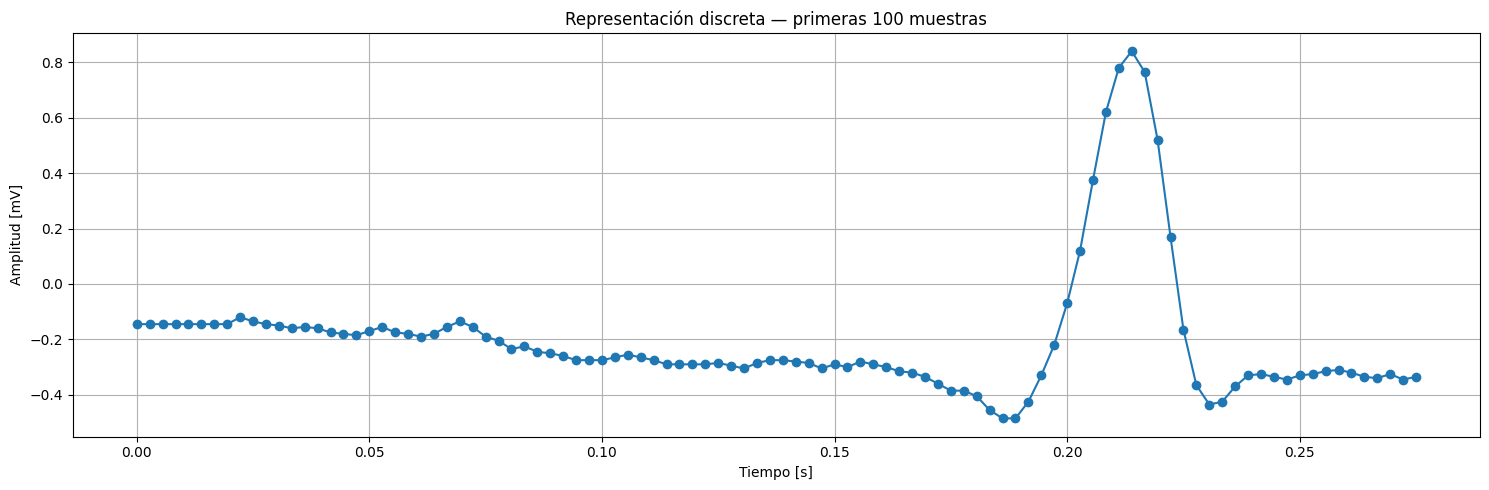

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3198
Desviación estándar: 0.1647
Mínimo            : -0.6450
Máximo            : 0.9600
Rango             : 1.6050


In [ ]:
# Ejercicio 3.1
# Cambio de la duración, comenzando con la DURATION = 5 segundos

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 5  # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

!pip install uv

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 20 s
Archivo WAV   : ecg_record_100_channel_0.wav
Parámetros configurados:
Base de datos : mitdb
Registro      : 100
Canal         : 0
Duración      : 20 s
Archivo WAV   : ecg_record_100_channel_0.wav
Librerías importadas correctamente.
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 100
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V5']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V5 [mV]

Canal seleccionado: 0
Nombre            : MLII
Número de muestras: 650000
Canal: MLII
Unidad: mV

Primeras 10 muestras:
[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Últ

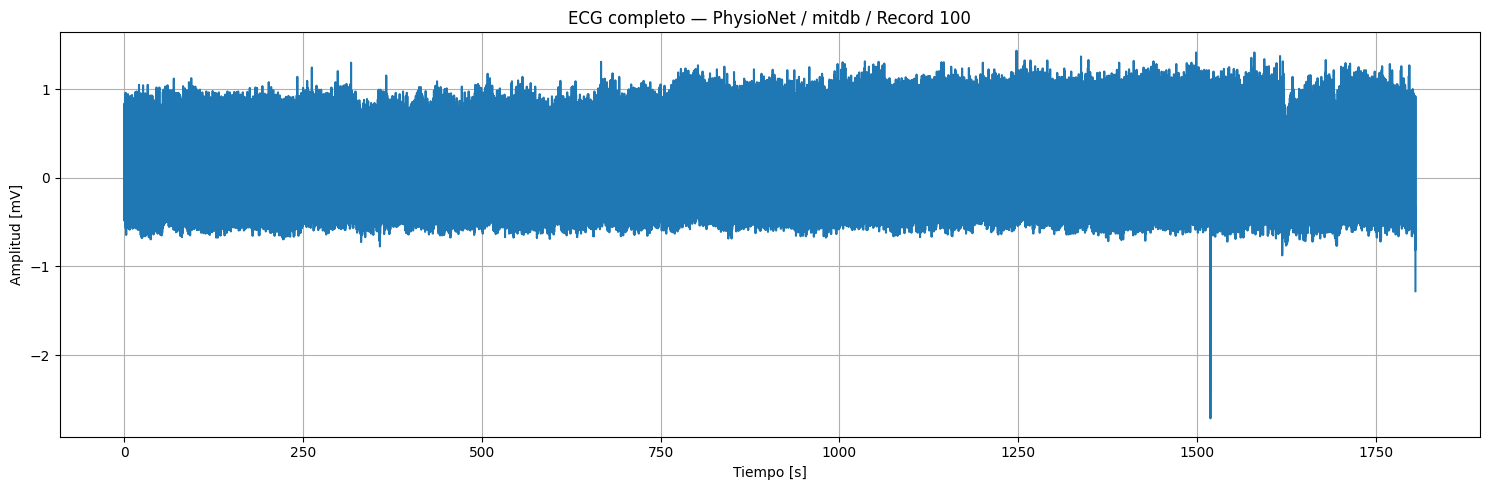

Duración solicitada : 20 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 7200


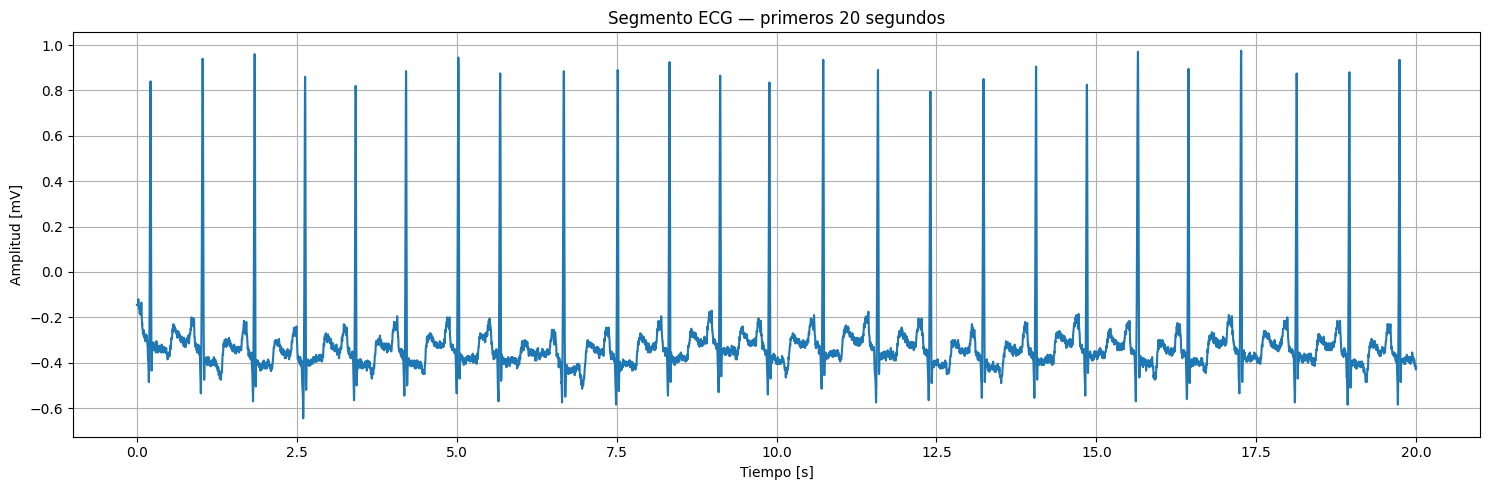

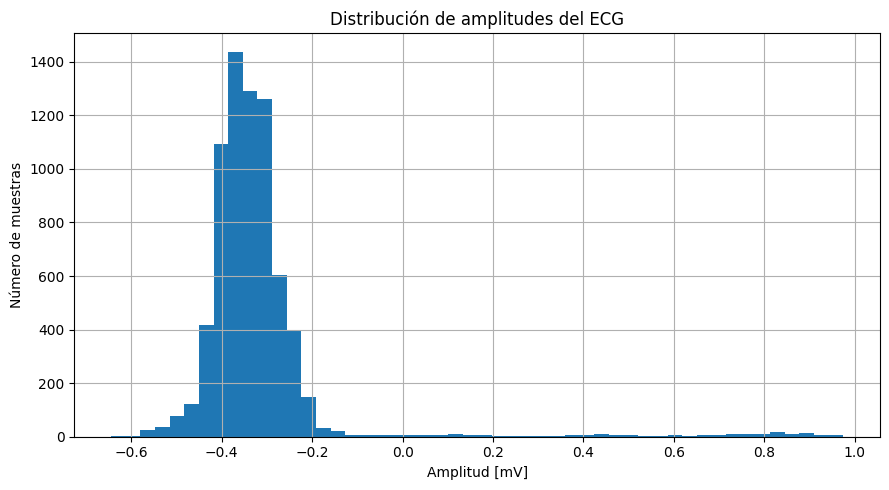

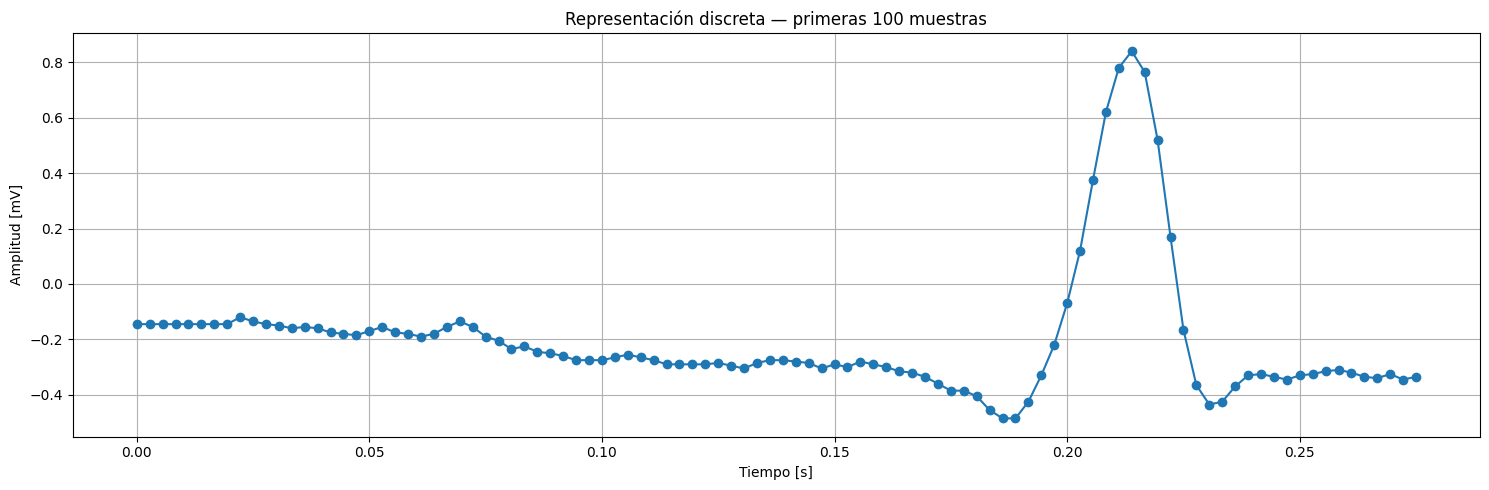

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.3192
Desviación estándar: 0.1685
Mínimo            : -0.6450
Máximo            : 0.9750
Rango             : 1.6200


In [ ]:
# Ejercicio 3.2
# Cambio de la duración, comenzando con la DURATION = 20 segundos

DATABASE = "mitdb"
RECORD = "100"

CHANNEL = 0

DURATION = 20 # segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

!pip install uv

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

**EJERCICIO 3**


# 19. Preguntas conceptuales

Responda con sus propias palabras.

### 1.
¿Qué es PhysioNet?
`PhysioNet es una plataforma en la que podemos encontrar datasets biomédicos y registros de señales como electrocardiogramas, que nos sirven para poder practicar con ellas.`

### 2.
¿Qué diferencia existe entre `DATABASE` y `RECORD`?
`DATABASE identifica una base de datos que tiene un grupo de registros, mientras que RECORD identifica una grabación específica en dicha base.`

### 3.
¿Qué representa `fs`?
`fs representa la frecuencia de muestreo de la señal, expresado en Hz.`

### 4.
¿Qué representa `CHANNEL`?
`CHANNEL indica que canal del registro queremos usar para el análisis de la señal, ya que un registro puede tener varios canales.`

### 5.
¿Qué representa `record.p_signal`?
`Es un elemento  de RECORD que almacena las señales con unidades físicas de un registro en una matriz.`

### 6.
¿Por qué necesitamos construir un eje temporal?
`Es importante para poder ubicar cada muestra en el tiempo y poder medir tanto la duración de ciertos eventos como los intervalos o separación. Para registros médicos sobretodo, resulta necesario que este eje temporal se construya ya que los tiempos de ciertas señales, como en un EGC, pueden mostrar problemas de salud y diversas condiciones.`

### 7.
¿Qué diferencia existe entre una señal continua y una señal discreta?
`Una señal continua está definida en todos los instante de tiempo, ya que tiene un dominio de tiempo continuo. Una señal discreta solo tiene valores en ciertos instantes de tiempo.`

### 8.
¿Por qué no debemos interpretar directamente un archivo WAV como si fuera una señal ECG?
`Porque el formato WAV está más dirigido para audio digital, con distintos rangos de frecuencia y voltajes de origen.`

### 9.
¿Qué ventajas ofrece trabajar con señales biomédicas reales en lugar de señales sintéticas?
`Las señales biomédica reales incluyen diferentes variaciones, ruido y artefactos que pueden aparecer durante una medición, de modo que nos permite aprender con situaciones cercanas a la realidad y mejorar nuestra capacidad de análisis.`

### 10.
¿Qué dificultades encontró durante el laboratorio?
`Algunos elementos dentro de las bibliotecas que se usaron fueron nuevos, como record.p_signal, algunas partes del codigo fueron un poco complicadas de entender.`


# 20. Reto final

Seleccione un registro diferente y realice el siguiente análisis:

```text
PhysioNet
   ↓
Seleccionar RECORD
   ↓
Identificar canales
   ↓
Seleccionar canal ECG
   ↓
Analizar 10 segundos
   ↓
Gráfica ECG
   ↓
Histograma
   ↓
Representación discreta
   ↓
Estadística
   ↓
Exportar WAV
```

### Informe

Presente:

1. Identificación de la base de datos.
2. Identificación del registro.
3. Frecuencia de muestreo.
4. Canal seleccionado.
5. Duración analizada.
6. Las 4 gráficas.
7. Estadísticas.
8. Archivo WAV.
9. Interpretación de los resultados.
10. Conclusiones.


In [ ]:
# Ejercicio 20: Modificación del RECORD e información del mismo para la
# posterior selección del CHANNEL

#  ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "103" # Selección de otro registro

CHANNEL = 0 # Selección del primer canal por mientras

DURATION = 10  # segundos como se pide en la guía

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

Parámetros configurados:
Base de datos : mitdb
Registro      : 103
Canal         : 0
Duración      : 10 s
Archivo WAV   : ecg_record_103_channel_0.wav
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 103
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V2']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos


Parámetros configurados:
Base de datos : mitdb
Registro      : 103
Canal         : 1
Duración      : 10 s
Archivo WAV   : ecg_record_103_channel_1.wav
Librerías importadas correctamente.
Registro cargado correctamente.
INFORMACIÓN DEL REGISTRO
Base de datos       : mitdb
Registro            : 103
Frecuencia muestreo : 360 Hz
Número de muestras  : 650000
Número de canales   : 2
Canales             : ['MLII', 'V2']
Unidades            : ['mV', 'mV']
Duración total      : 1805.56 segundos
Canales disponibles:
Canal 0: MLII [mV]
Canal 1: V2 [mV]

Canal seleccionado: 1
Nombre            : V2
Número de muestras: 650000
Canal: V2
Unidad: mV

Primeras 10 muestras:
[0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.05  0.035]
Frecuencia de muestreo: 360 Hz
Periodo de muestreo: 0.002778 segundos
Primer instante: 0.000000 segundos
Último instante: 1805.552778 segundos


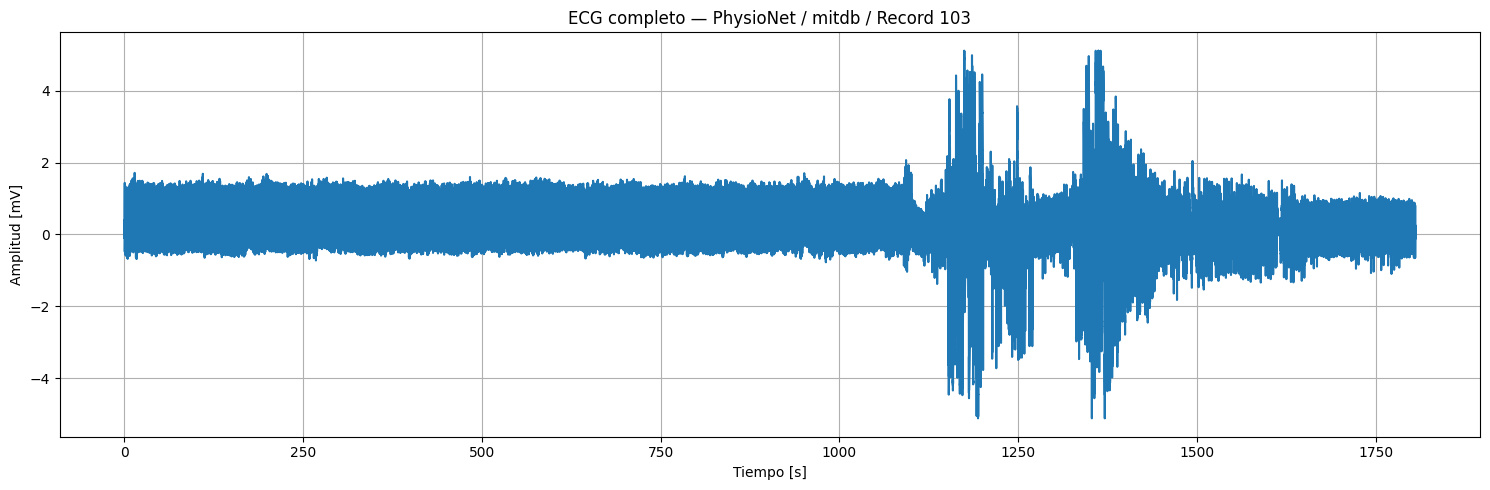

Duración solicitada : 10 s
Frecuencia muestreo : 360 Hz
Número de muestras  : 3600


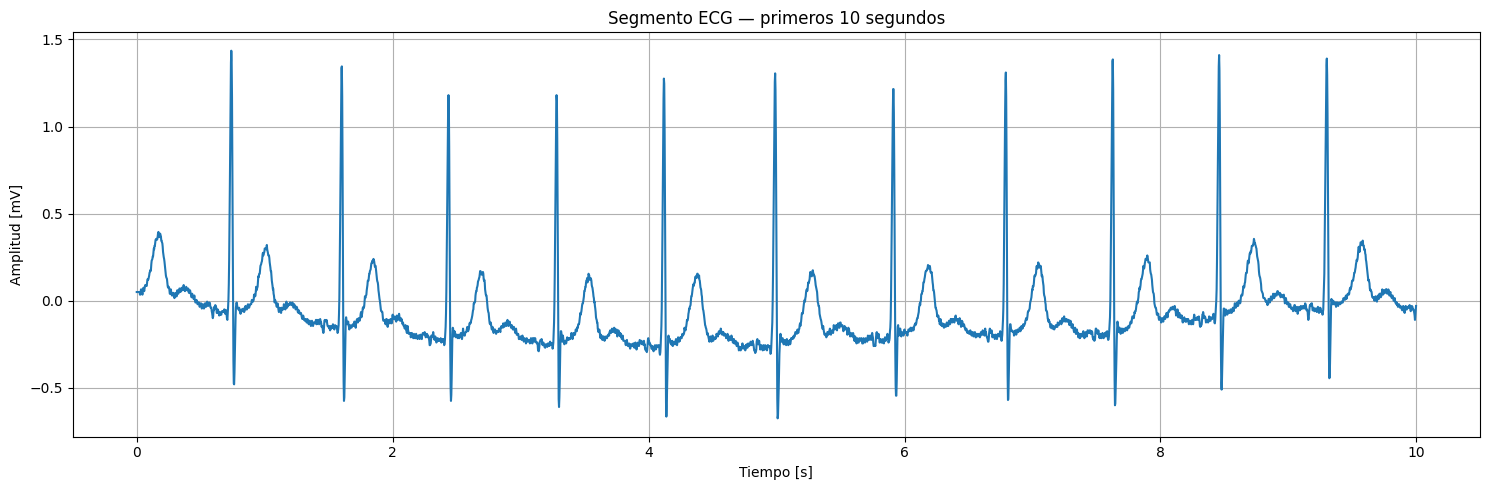

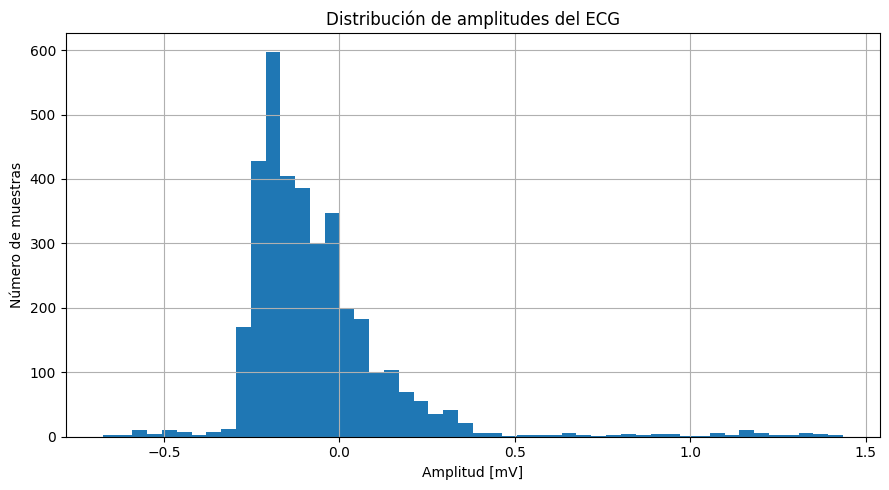

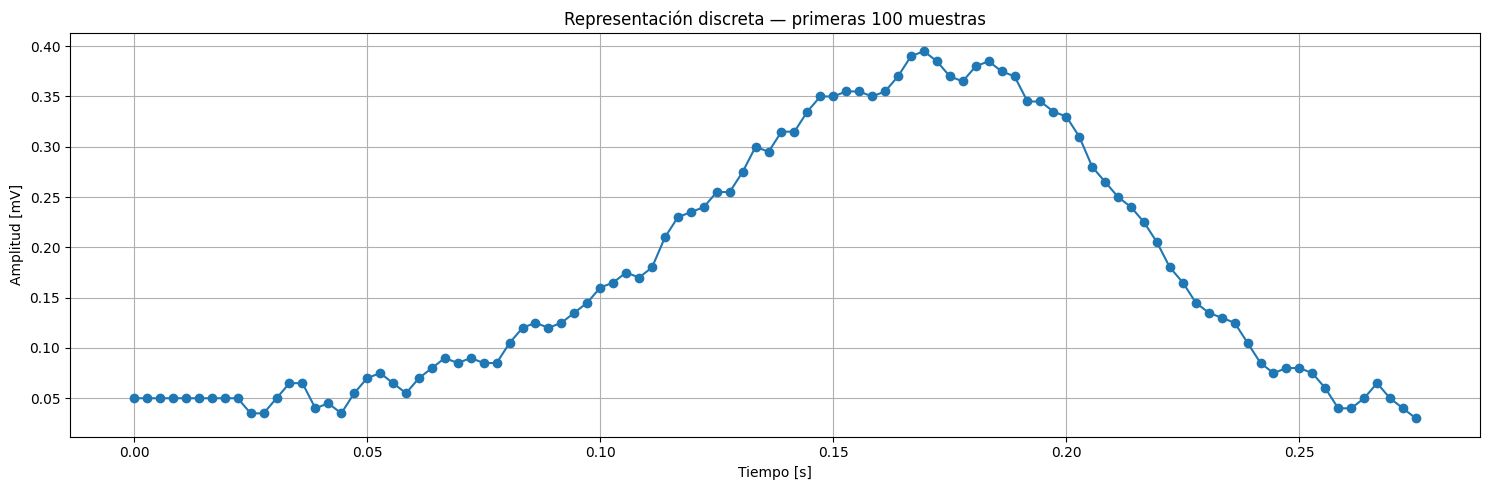

ESTADÍSTICAS DEL SEGMENTO
Media             : -0.0629
Desviación estándar: 0.2250
Mínimo            : -0.6750
Máximo            : 1.4350
Rango             : 2.1100
Conversión preparada correctamente.
Tipo original   : float64
Tipo WAV        : int16
Mínimo int16    : -13389
Máximo int16    : 32767
Archivo WAV generado correctamente:
ecg_record_103_channel_1.wav
Reproducción del archivo WAV:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#  ============================================
# PARÁMETROS DEL LABORATORIO
# ============================================

DATABASE = "mitdb"
RECORD = "103" # Modificación del RECORD nuevamente

CHANNEL = 1 # Tras la información recopilada se selecciona el canal 1, es
# decir el canal V2

DURATION = 10  # Análisis de 10 segundos

OUTPUT_WAV = f"ecg_record_{RECORD}_channel_{CHANNEL}.wav"

print("Parámetros configurados:")
print(f"Base de datos : {DATABASE}")
print(f"Registro      : {RECORD}")
print(f"Canal         : {CHANNEL}")
print(f"Duración      : {DURATION} s")
print(f"Archivo WAV   : {OUTPUT_WAV}")

!pip install uv

# En Google Colab/Jupyter, ejecutar si las librerías no están instaladas.
!uv pip install -q wfdb scipy pandas numpy matplotlib

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from IPython.display import Audio, display

print("Librerías importadas correctamente.")

# ============================================
# CARGAR REGISTRO DESDE PHYSIONET
# ============================================

record = wfdb.rdrecord(
    RECORD,
    pn_dir=DATABASE
)

print("Registro cargado correctamente.")

# ============================================
# INFORMACIÓN DEL REGISTRO
# ============================================

fs = record.fs

print("=" * 55)
print("INFORMACIÓN DEL REGISTRO")
print("=" * 55)

print(f"Base de datos       : {DATABASE}")
print(f"Registro            : {RECORD}")
print(f"Frecuencia muestreo : {record.fs} Hz")
print(f"Número de muestras  : {record.sig_len}")
print(f"Número de canales   : {record.n_sig}")
print(f"Canales             : {record.sig_name}")
print(f"Unidades            : {record.units}")

duration_total = record.sig_len / record.fs

print(f"Duración total      : {duration_total:.2f} segundos")
print("=" * 55)

# Mostrar los canales disponibles

print("Canales disponibles:")

for i, channel_name in enumerate(record.sig_name):
    unit = record.units[i] if record.units else "N/A"
    print(f"Canal {i}: {channel_name} [{unit}]")

print()
print(f"Canal seleccionado: {CHANNEL}")
print(f"Nombre            : {record.sig_name[CHANNEL]}")

# ============================================
# EXTRAER CANAL
# ============================================

signal = record.p_signal[:, CHANNEL]

print(f"Número de muestras: {len(signal)}")
print(f"Canal: {record.sig_name[CHANNEL]}")
print(f"Unidad: {record.units[CHANNEL]}")
print()
print("Primeras 10 muestras:")
print(signal[:10])

# ============================================
# EJE TEMPORAL
# ============================================

t = np.arange(len(signal)) / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Periodo de muestreo: {1/fs:.6f} segundos")
print(f"Primer instante: {t[0]:.6f} segundos")
print(f"Último instante: {t[-1]:.6f} segundos")

# ============================================
# GRÁFICA 1: ECG COMPLETO
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t, signal)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"ECG completo — PhysioNet / {DATABASE} / Record {RECORD}"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# SELECCIONAR SEGMENTO
# ============================================

N = int(DURATION * fs)

signal_segment = signal[:N]
t_segment = t[:N]

print(f"Duración solicitada : {DURATION} s")
print(f"Frecuencia muestreo : {fs} Hz")
print(f"Número de muestras  : {N}")

# ============================================
# GRÁFICA 2: SEGMENTO ECG
# ============================================

plt.figure(figsize=(15, 5))

plt.plot(t_segment, signal_segment)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Segmento ECG — primeros {DURATION} segundos"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 3: HISTOGRAMA
# ============================================

plt.figure(figsize=(9, 5))

plt.hist(
    signal_segment,
    bins=50
)

plt.xlabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.ylabel("Número de muestras")
plt.title("Distribución de amplitudes del ECG")

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# GRÁFICA 4: MUESTRAS DISCRETAS
# ============================================

N_SAMPLES = 100

plt.figure(figsize=(15, 5))

plt.plot(
    t_segment[:N_SAMPLES],
    signal_segment[:N_SAMPLES],
    marker="o"
)

plt.xlabel("Tiempo [s]")
plt.ylabel(f"Amplitud [{record.units[CHANNEL]}]")
plt.title(
    f"Representación discreta — primeras {N_SAMPLES} muestras"
)

plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS BÁSICAS
# ============================================

mean_value = np.mean(signal_segment)
std_value = np.std(signal_segment)
min_value = np.min(signal_segment)
max_value = np.max(signal_segment)

print("ESTADÍSTICAS DEL SEGMENTO")
print("=" * 40)
print(f"Media             : {mean_value:.4f}")
print(f"Desviación estándar: {std_value:.4f}")
print(f"Mínimo            : {min_value:.4f}")
print(f"Máximo            : {max_value:.4f}")
print(f"Rango             : {max_value - min_value:.4f}")

# ============================================
# PREPARAR ECG PARA WAV
# ============================================

ecg_for_wav = signal_segment.astype(float).copy()

# 1. Eliminar componente DC
ecg_for_wav = ecg_for_wav - np.mean(ecg_for_wav)

# 2. Normalizar
max_abs = np.max(np.abs(ecg_for_wav))

if max_abs == 0:
    raise ValueError("La señal no puede normalizarse porque todos sus valores son cero.")

ecg_normalized = ecg_for_wav / max_abs

# 3. Convertir a int16
ecg_int16 = np.int16(
    ecg_normalized * 32767
)

print("Conversión preparada correctamente.")
print(f"Tipo original   : {signal_segment.dtype}")
print(f"Tipo WAV        : {ecg_int16.dtype}")
print(f"Mínimo int16    : {ecg_int16.min()}")
print(f"Máximo int16    : {ecg_int16.max()}")

# ============================================
# GUARDAR WAV
# ============================================

wavfile.write(
    OUTPUT_WAV,
    int(fs),
    ecg_int16
)

print(f"Archivo WAV generado correctamente:")
print(OUTPUT_WAV)

# Reproducir el archivo WAV
print(f"Reproducción del archivo WAV:")

display(
    Audio(
        OUTPUT_WAV,
        rate=int(fs)
    )
)

# ============================================
# DESCARGAR WAV EN GOOGLE COLAB
# ============================================

try:
    from google.colab import files
    files.download(OUTPUT_WAV)
except ImportError:
    print("Este entorno no es Google Colab.")
    print(f"El archivo está disponible localmente como: {OUTPUT_WAV}")

Interpretación de los resultados:

En la gráfica del ECG completo del registro 103 se observa que la amplitud se mantiene dentro de una banda relativamente uniforme durante los primeros 1000 segundos. Posteriormente, aparecen variaciones pronunciadas, especialmente entre los 1150 y 1400 segundos, con valores cercanos a ±5 mV. Estas variaciones podrían estar relacionadas con perturbaciones en la adquisición, pero no se puede determinar su origen solo con la gráfica. Los ciclos individuales quedan superpuestos visualmente, por lo que es necesario seleccionar un segmento más corto para observar su forma con mayor detalle.

En los primeros 10 segundos del canal V2 se distinguen picos estrechos que se repiten a intervalos regulares, con amplitudes positivas entre 1,2 y 1,4 mV. También se observan partes negativas y ondas de menor amplitud entre los picos principales. Aunque el patrón es repetitivo, tiene pequeñas variaciones en la amplitud. Por tanto, la señal presenta variaciones que deben considerarse al analizarla.

El histograma muestra que la mayor parte de las muestras se concentra en valores ligeramente negativos, principalmente entre −0,3 y 0 mV. Los valores positivos de mayor amplitud aparecen con menor frecuencia, debido a que los picos estrechos ocupan una pequeña parte del tiempo registrado. Por ello la distribución se ve asimétrica y se extiende hacia amplitudes positivas. La media de −0,0629 mV indica que el segmento no está centrado exactamente en cero, mientras que la desviación estándar de 0,225 mV muestra la dispersión de las amplitudes respecto a la media. Los valores mínimo y máximo fueron −0,675 y 1,4350 mV, con un rango de 2,110 mV. Estos resultados describen la variabilidad total del segmento, que incluye tanto la forma del ECG como sus perturbaciones.

En la representación de las primeras 100 muestras se aprecia que la señal está formada por valores separados en el tiempo. Para una frecuencia de muestreo de 360 Hz, la separación entre muestras es aproximadamente 2,8 ms, y el último punto mostrado corresponde a 0,28 segundos. Aunque los puntos se unen mediante líneas para facilitar la visualización, los datos siguen siendo discretos. Esta gráfica permite observar con mayor detalle los cambios de amplitud y ciertas fluctuaciones que no se distinguen en la representación completa.

Finalmente, para generar el archivo WAV se eliminó la media del segmento, se normalizó su amplitud y se convirtió a un formato de enteros de 16 bits. Por ello, los valores almacenados, entre −13389 y 32767, ya no representan directamente amplitudes en milivoltios. Esta conversión conserva aproximadamente la forma de la señal, con cambios debidos a la cuantización, pero modifica su escala y su nivel de referencia. En consecuencia, el archivo WAV constituye otra representación del segmento, mientras que los datos originales deben conservarse para interpretar sus amplitudes físicas.



# 21. Conclusiones esperadas

`Con los ejercios realizados en este laboratorio, concluimos que para interpretar una señal biomédica se debe considerar tanto su comportamiento en el eje temporal como su amplitud y distribución, ya que estas nos brindan información complementaria para caracterizar y analizar de forma correcta la señal. Además, es importante conocer la frecuencia de muestreo y las unidades físicas de la señal para relacionarlas correctamente con  el fenómeno fisiológico que representa la señal. Comprender las características y el dominio discreto de una señal biomédica es importante para su posterior procesamiento digital y técnicas de filtrado.`


Al finalizar el laboratorio, el estudiante debería comprender que una señal biomédica puede estudiarse desde diferentes perspectivas:

```text
              SEÑAL ECG
                  │
       ┌──────────┼──────────┐
       ↓          ↓          ↓
     Tiempo    Amplitud   Distribución
       │          │          │
       └──────────┼──────────┘
                  ↓
          Señal discreta x[n]
                  ↓
          Procesamiento digital
                  ↓
        Filtros FIR / IIR
                  ↓
         Análisis de señales
```

Este laboratorio constituye la base para los siguientes laboratorios, donde se aplicarán técnicas de **procesamiento digital de señales**, incluyendo filtros FIR, filtros IIR, respuesta en frecuencia y Transformada Z.



# Referencias

- PhysioNet — plataforma de acceso a bases de datos de señales fisiológicas.
- WFDB Python — herramientas Python para lectura y procesamiento de registros fisiológicos.
- MIT-BIH Arrhythmia Database — base de datos utilizada como ejemplo en este laboratorio.

**Nota:** consulte siempre la documentación oficial de la base de datos seleccionada para conocer el significado de sus registros, canales y anotaciones.
